<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/T5finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets
!pip install transformers
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from transformers import T5ForConditionalGeneration, T5Tokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
import time
from transformers import TrainerCallback  # Импорт TrainerCallback для кастомного трекера времени


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [2]:
# 1. Загрузка и подготовка данных
train_df = pd.read_csv("in_domain_train.csv")
test_df = pd.read_csv("in_domain_dev.csv")

# Разделение тренировочных данных
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

# Преобразование в формат HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)
test_dataset = Dataset.from_pandas(test_df)

In [3]:
# 2. Инициализация модели и токенизатора
model_name = "sberbank-ai/ruT5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/20.4k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.00M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [4]:
# 3. Препроцессинг данных
def preprocess_function(examples):
    inputs = [f"Корректно ли следующее предложение? {sent}" for sent in examples['sentence']]
    targets = ["да" if label == 1 else "нет" for label in examples['acceptable']]

    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        targets,
        max_length=3,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/6295 [00:00<?, ? examples/s]

Map:   0%|          | 0/1574 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

In [10]:
# 4. Настройка тренировочных аргументов с отслеживанием времени
# Класс для отслеживания времени обучения
class TimeTrackerCallback(TrainerCallback):
    def __init__(self):
        self.start_time = time.time()

    def on_step_begin(self, args, state, control, **kwargs):
        elapsed = time.time() - self.start_time
        remaining = (state.max_steps - state.global_step) * (elapsed / state.global_step) if state.global_step else 0
        print(f"Прогресс: {state.global_step/state.max_steps:.1%} | Прошло: {elapsed/60:.1f} мин | Осталось: {remaining/60:.1f} мин")

training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="epoch",  # Изменено: сохраняем после каждой эпохи
    save_total_limit=1,    # Опционально: сохраняем только последнюю модель
    predict_with_generate=True,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [11]:
# 5. Создание Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    callbacks=[TimeTrackerCallback()]
)


<ipython-input-11-d5949c58aaa4>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [12]:
# 6. Обучение модели
trainer.train()

Прогресс: 0.0% | Прошло: 0.1 мин | Осталось: 0.0 мин


Epoch,Training Loss,Validation Loss
1,0.159700,0.201245
2,0.147400,0.171315
3,0.132400,0.202418
4,0.117000,0.202623
5,0.106500,0.226229
6,0.101200,0.266613
7,0.080800,0.332788
8,0.067700,0.310711
9,0.074200,0.392918
10,0.065800,0.418672


Выходные данные были обрезаны до нескольких последних строк (5000).
Прогресс: 36.5% | Прошло: 28.9 мин | Осталось: 50.2 мин
Прогресс: 36.6% | Прошло: 28.9 мин | Осталось: 50.2 мин
Прогресс: 36.6% | Прошло: 28.9 мин | Осталось: 50.2 мин
Прогресс: 36.6% | Прошло: 28.9 мин | Осталось: 50.1 мин
Прогресс: 36.6% | Прошло: 28.9 мин | Осталось: 50.1 мин
Прогресс: 36.6% | Прошло: 28.9 мин | Осталось: 50.1 мин
Прогресс: 36.6% | Прошло: 29.0 мин | Осталось: 50.1 мин
Прогресс: 36.6% | Прошло: 29.0 мин | Осталось: 50.1 мин
Прогресс: 36.6% | Прошло: 29.0 мин | Осталось: 50.1 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.1 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.7% | Прошло: 29.0 мин | Осталось: 50.0 мин
Прогресс: 36.8% | Прошло: 29.0 мин |

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=7880, training_loss=0.06985166246818407, metrics={'train_runtime': 5099.046, 'train_samples_per_second': 24.691, 'train_steps_per_second': 1.545, 'total_flos': 1.9166949605376e+16, 'train_loss': 0.06985166246818407, 'epoch': 20.0})

In [13]:
# 7. Предсказание на тестовых данных
test_preds = trainer.predict(tokenized_test)
pred_texts = tokenizer.batch_decode(test_preds.predictions, skip_special_tokens=True)
y_pred = [1 if text == "да" else 0 for text in pred_texts]
y_true = test_df['acceptable'].values

Confusion Matrix:
[[ 46 204]
 [  5 728]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.18      0.31       250
           1       0.78      0.99      0.87       733

    accuracy                           0.79       983
   macro avg       0.84      0.59      0.59       983
weighted avg       0.81      0.79      0.73       983



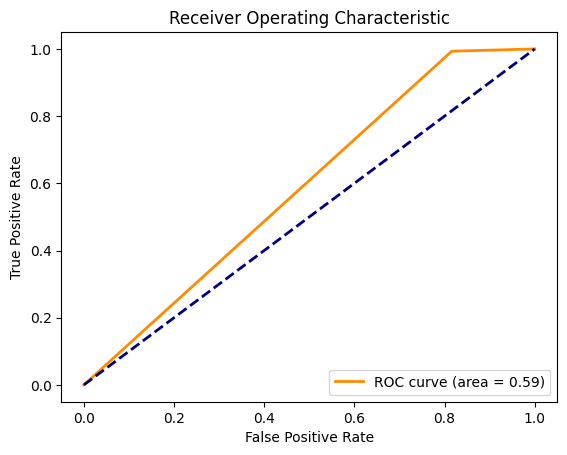

In [14]:
# 8. Оценка модели
# Матрица ошибок
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Отчет классификации
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# ROC-AUC
fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()